In [1]:
import kagglehub
import os
path = kagglehub.dataset_download("lainguyn123/student-performance-factors")
print(path)

Using Colab cache for faster access to the 'student-performance-factors' dataset.
/kaggle/input/student-performance-factors


In [2]:
import pandas as pd
print(os.listdir(path))
file_path = os.path.join(path, "StudentPerformanceFactors.csv")
df = pd.read_csv(file_path)
df

['StudentPerformanceFactors.csv']


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

NULL VALUES HANDLING

In [5]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [4]:
df.dropna(inplace=True)
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [5]:
df.shape

(6378, 20)

DUPLICATE VALUES HANDING

In [6]:
df[df.duplicated()].shape

(0, 20)

In [7]:
X=df.iloc[:,0:19]
Y=df.iloc[:,-1]

In [8]:
print(df.shape)
print(X.shape)
print(Y.shape)

(6378, 20)
(6378, 19)
(6378,)


In [9]:
cat_data=X.select_dtypes(include="object").columns
num_data=X.select_dtypes(exclude="object").columns
print(cat_data)
print(num_data)

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')
Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object')


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

from sklearn.pipeline import Pipeline

In [14]:
num_pipeline=Pipeline([("scaler",StandardScaler())])
cat_pipeline=Pipeline([("encoder",OneHotEncoder())])

In [15]:
preprocessing=ColumnTransformer([("num_pipeline",num_pipeline,num_data),
                               ("cat_pipeline",cat_pipeline,cat_data)])

TEST-TRAIN SPLIT

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [17]:
X_train=preprocessing.fit_transform(X_train)
X_test=preprocessing.transform(X_test)

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
model=LinearRegression()
model.fit(X_train,Y_train)
Xtest_pred=model.predict(X_test)
Xtrain_pred=model.predict(X_train)
Xtrain_r2=r2_score(Y_train,Xtrain_pred)
Xtest_r2=r2_score(Y_test,Xtest_pred)
print("train:",Xtrain_r2)
print("test:",Xtest_r2)


train: 0.7187813703799608
test: 0.7314386522127074


In [67]:
from sklearn import metrics
print("MAE:",metrics.mean_absolute_error(Y_test,Xtest_pred))
print("MSE:",metrics.mean_squared_error(Y_test,Xtest_pred))

MAE: 0.48728723427430937
MSE: 4.173262062207912


RIDGE ALGORITHM

In [20]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge=Ridge()

In [21]:
parameters={'alpha':[10,20,30,40,50,60,70,80,90,100]}
ridge_regressor=GridSearchCV(ridge,parameters,scoring='neg_mean_squared_error',cv=5)

In [22]:
ridge_regressor.fit(X_train,Y_train)
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 10}
-4.345881252763792


In [23]:
test_ridge_pred=ridge_regressor.predict(X_test)
train_ridge_pred=ridge_regressor.predict(X_train)
test_ridge_r2=r2_score(Y_test,test_ridge_pred)
train_ridge_r2=r2_score(Y_train,train_ridge_pred)

In [69]:
print("test:",test_ridge_r2)
print("train:",train_ridge_r2)


test: 0.7314901050227003
train: 0.7187694481829707


In [70]:
print("MAE:",metrics.mean_absolute_error(Y_test,test_ridge_pred))
print("MSE:",metrics.mean_squared_error(Y_test,test_ridge_pred))

MAE: 0.48762015990311025
MSE: 4.17246252027194


LESSO

In [26]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
lasso=Lasso()

In [27]:
parameters={'alpha':[0.0001, 0.001, 0.01, 0.1, 1, 2, 5, 10]}
lasso_regressor=GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)

In [28]:
lasso_regressor.fit(X_train,Y_train)
test_lasso_pred=lasso_regressor.predict(X_test)
train_lasso_pred=lasso_regressor.predict(X_train)
test_lasso_r2=r2_score(Y_test,test_lasso_pred)
train_lasso_r2=r2_score(Y_train,train_lasso_pred)

In [71]:
print("test:",test_lasso_r2)
print("train:",train_lasso_r2)

test: 0.7314587016385085
train: 0.7187735140551991


In [72]:
print("MAE:",metrics.mean_absolute_error(Y_test,test_lasso_pred))
print("MSE:",metrics.mean_squared_error(Y_test,test_lasso_pred))

MAE: 0.487635901023537
MSE: 4.172950507664588


KNN

In [30]:
from sklearn.neighbors import KNeighborsRegressor
knn_regressor = KNeighborsRegressor(n_neighbors=5)

knn_regressor.fit(X_train, Y_train)
test_knn_pred = knn_regressor.predict(X_test)
test_knn_r2 = r2_score(Y_test, test_knn_pred)

train_knn_pred = knn_regressor.predict(X_train)
train_knn_r2 = r2_score(Y_train, train_knn_pred)


In [55]:
print("test:",test_knn_r2)
print("train:",train_knn_r2 )

test: 0.5311642007851465
train: 0.6802140458123414


In [73]:
print("MAE:",metrics.mean_absolute_error(Y_test,test_knn_pred))
print("MSE:",metrics.mean_squared_error(Y_test,test_knn_pred))

MAE: 1.5652037617554861
MSE: 7.2853918495297805


DECISION TREE

In [56]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
parameters={
    'criterion':['squared_error','friedman_mse','absolute_error','poisson'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6,7,8,9,10]
}
regressor = DecisionTreeRegressor(random_state=0, max_depth=6)
cv=GridSearchCV(regressor,parameters,scoring='neg_mean_squared_error',cv=5)
cv.fit(X_train, Y_train)
print(cv.best_params_)
print(cv.best_score_)

{'criterion': 'absolute_error', 'max_depth': 6, 'splitter': 'best'}
-7.565717769967928


In [57]:
test_dt_pred = cv.predict(X_test)
test_dt_r2 = r2_score(Y_test, test_dt_pred)

train_dt_pred = cv.predict(X_train)
train_dt_r2 = r2_score(Y_train, train_dt_pred)


In [58]:
print("train :", train_dt_r2)
print("test :", test_dt_r2)

train : 0.5521088940386467
test : 0.5493786825974687


In [74]:
print("MAE:",metrics.mean_absolute_error(Y_test,test_dt_pred))
print("MSE:",metrics.mean_squared_error(Y_test,test_dt_pred))

MAE: 1.5148902821316614
MSE: 7.002351097178684


[Text(0.5, 0.9285714285714286, 'x[1] <= -0.043\nabsolute_error = 2.823\nsamples = 5102\nvalue = 67.0'),
 Text(0.25, 0.7857142857142857, 'x[0] <= -0.411\nabsolute_error = 2.312\nsamples = 2494\nvalue = 65.0'),
 Text(0.375, 0.8571428571428572, 'True  '),
 Text(0.125, 0.6428571428571429, 'x[1] <= -0.736\nabsolute_error = 2.065\nsamples = 828\nvalue = 63.0'),
 Text(0.0625, 0.5, 'x[0] <= -1.077\nabsolute_error = 1.8\nsamples = 495\nvalue = 62.0'),
 Text(0.03125, 0.35714285714285715, 'x[6] <= 0.5\nabsolute_error = 1.815\nsamples = 205\nvalue = 61.0'),
 Text(0.015625, 0.21428571428571427, 'x[0] <= -1.91\nabsolute_error = 1.552\nsamples = 145\nvalue = 61.0'),
 Text(0.0078125, 0.07142857142857142, 'absolute_error = 2.0\nsamples = 26\nvalue = 60.0'),
 Text(0.0234375, 0.07142857142857142, 'absolute_error = 1.336\nsamples = 119\nvalue = 61.0'),
 Text(0.046875, 0.21428571428571427, 'x[3] <= 0.932\nabsolute_error = 2.083\nsamples = 60\nvalue = 62.0'),
 Text(0.0390625, 0.07142857142857142, 'absolute_

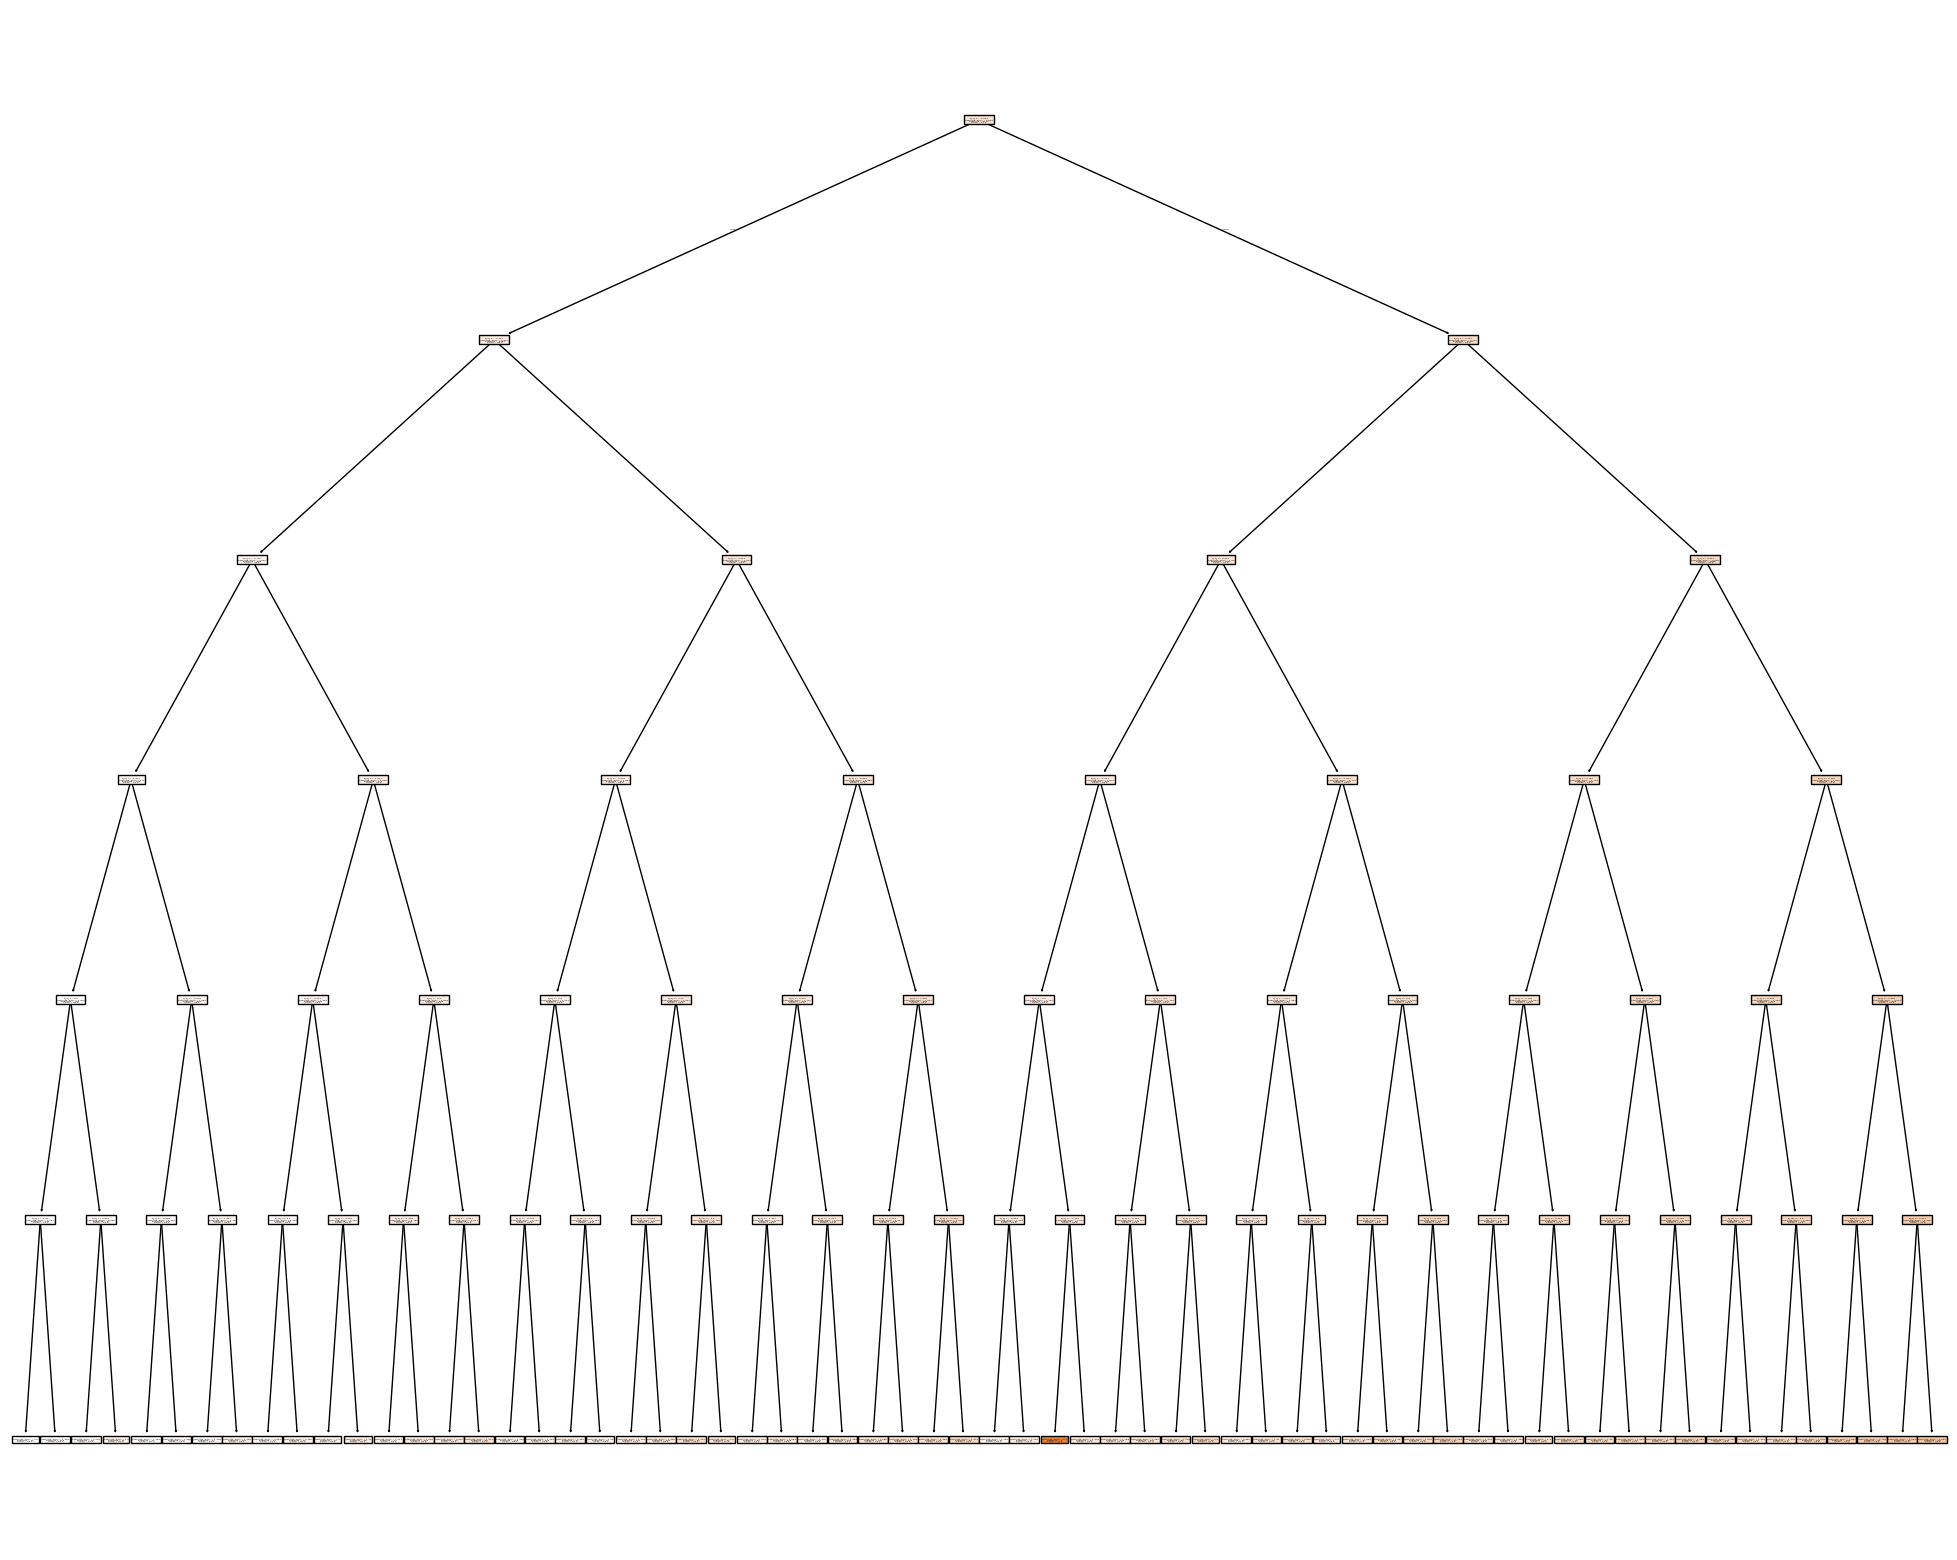

In [61]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(25,20))
tree.plot_tree(cv.best_estimator_,filled=True)
plt.show()

RANDOM FOREST

In [64]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42)
regressor.fit(X_train, Y_train)
test_pred = regressor.predict(X_test)
test_r2 = r2_score(Y_test, test_pred)

train_pred = regressor.predict(X_train)
train_r2 = r2_score(Y_train, train_pred)

In [65]:
print("train :", train_r2)
print("test :", test_r2)

train : 0.8472732392671303
test : 0.6347421971607102


In [75]:
print("MAE:",metrics.mean_absolute_error(Y_test,test_pred))
print("MSE:",metrics.mean_squared_error(Y_test,test_pred))

MAE: 1.1691077377312653
MSE: 5.675859702349732
